In [13]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Curva: segmento + 2 espirales logarítmicas
# ============================================================
def log_spiral(r, delta, beta):
    theta = -delta * np.log(r) + beta
    return r * np.exp(1j * theta)

def rotate(z, angle):
    return z * np.exp(1j * angle)

def build_carleson_segment_two_spirals(
    delta,
    r_min=2e-4,
    r_max=0.35,
    n=12000,
    beta1=0.0,
    beta2=0.28,
    seg_m=400,
    global_rot=0.0,
):
    r_in = np.linspace(r_max, r_min, n)
    z1 = log_spiral(r_in, delta, beta1)

    r_out = np.linspace(r_min, r_max, n)
    z2 = log_spiral(r_out, delta, beta2)

    p1 = log_spiral(np.array([r_max]), delta, beta1)[0]
    p2 = log_spiral(np.array([r_max]), delta, beta2)[0]
    seg = np.linspace(p2, p1, seg_m)

    z = np.concatenate([z1, z2, seg])
    z = rotate(z, global_rot)
    return z.real, z.imag


# ============================================================
# GIF (sin título, sin ejes)
# ============================================================
def make_spiral_gif(
    out_gif="spirales.gif",
    delta=10,
    r_min=2e-4,
    r_max=0.35,
    beta1=0.0,
    beta2=0.28,
    global_rot=0.10,
    n=12000,
    seg_m=400,
    frames=180,
    fps=30,
    dpi=180,
    lw=1.6,
):
    x, y = build_carleson_segment_two_spirals(
        delta=delta,
        r_min=r_min,
        r_max=r_max,
        n=n,
        beta1=beta1,
        beta2=beta2,
        seg_m=seg_m,
        global_rot=global_rot,
    )

    # límites fijos para evitar "brincos"
    pad = 0.06
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= pad * dx; xmax += pad * dx
    ymin -= pad * dy; ymax += pad * dy

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # sin ejes, sin borde, sin nada
    ax.set_axis_off()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    line, = ax.plot([], [], lw=lw)

    # animación sin depender de matplotlib.animation (más portable)
    # guardamos frames como imágenes en memoria y usamos PillowWriter
    from matplotlib.animation import FuncAnimation, PillowWriter

    N = len(x)
    # frames recorren progresivamente la curva
    idxs = np.linspace(2, N, frames).astype(int)

    def init():
        line.set_data([], [])
        return (line,)

    def update(k):
        m = idxs[k]
        line.set_data(x[:m], y[:m])
        return (line,)

    anim = FuncAnimation(fig, update, init_func=init, frames=frames, interval=1000/fps, blit=True)
    anim.save(out_gif, writer=PillowWriter(fps=fps), dpi=dpi)
    plt.close(fig)


if __name__ == "__main__":
    # GIF para δ=10 (tipo Fig 3a)
    make_spiral_gif(
        out_gif="fig3a_delta10.gif",
        delta=10,
        r_max=0.35,
        beta2=0.28,
        global_rot=0.10,
        frames=220,
        fps=30,
    )

    # GIF para δ=-3 (tipo Fig 3b)
    make_spiral_gif(
        out_gif="fig3b_delta-3.gif",
        delta=-3,
        r_max=0.50,
        beta2=0.75,
        global_rot=-6.20,
        frames=220,
        fps=30,
    )

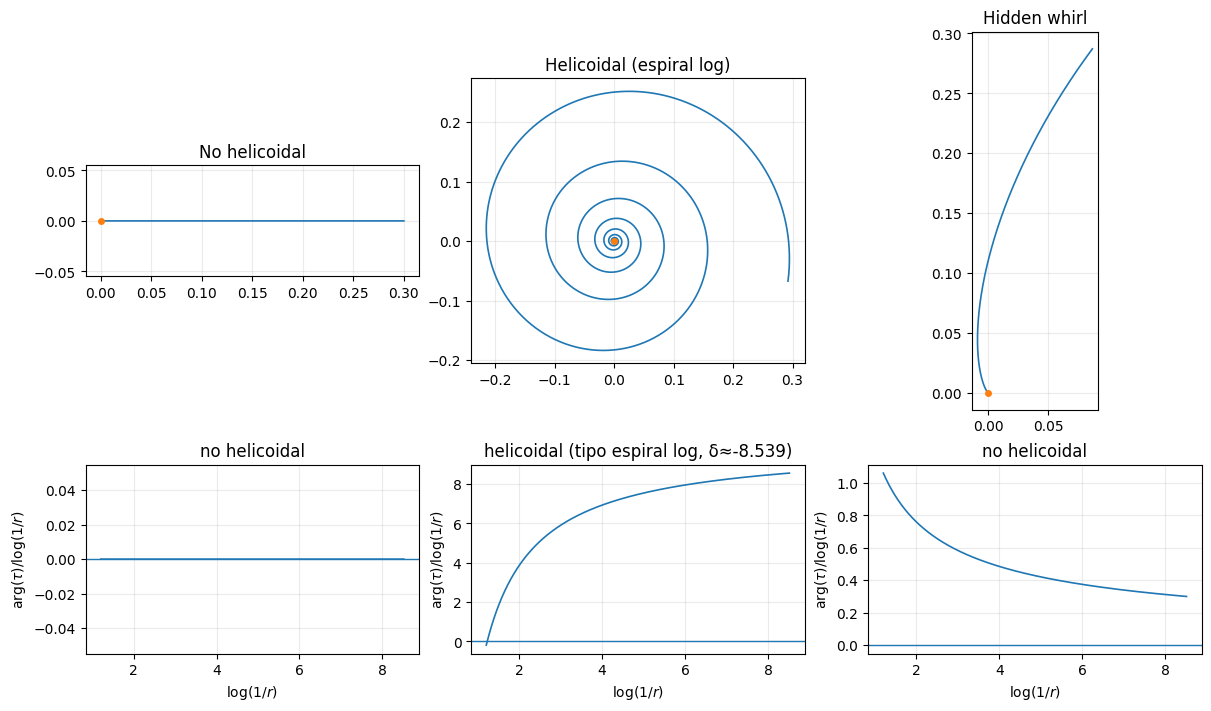

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Curvas prototipo cerca de t=0
#    - no helicoidal: arg(τ) acotado
#    - helicoidal (espiral log): arg(τ) ~ -δ log|τ|
#    - hidden whirl: arg(τ) diverge pero o(-log|τ|)
# ============================================================

def curve_nonhelical(r):
    """
    No helicoidal en 0: arg(τ)=0 constante (acotado).
    τ(r)=r  (segmento radial sobre eje real)
    """
    return r.astype(np.complex128) + 0j


def curve_helical_logspiral(r, delta=6.0, beta=0.0):
    """
    Helicoidal en 0: arg(τ) = -delta log r + beta (no acotado).
    τ(r)= r * exp(i(-delta log r + beta))
    """
    theta = -delta * np.log(r) + beta
    return r * np.exp(1j * theta)


def curve_hidden_whirl(r, alpha=0.60, beta=0.0):
    """
    Hidden whirl en 0: arg(τ) = (log(1/r))^alpha + beta,
    con 0<alpha<1, así:
      arg(τ) -> +infty pero arg(τ) / log(1/r) -> 0,
    es decir arg(τ)=o(log(1/r)) = o(-log r).
    τ(r)= r * exp(i * theta(r))
    """
    L = np.log(1.0 / r)             # = -log r
    theta = (L ** alpha) + beta
    return r * np.exp(1j * theta)


# ============================================================
# 2) "Clasificador" numérico basado en crecimiento de arg / log(1/r)
#    (solo para visualizar; no pretende ser prueba matemática)
# ============================================================

def estimate_type(r, z, eps=1e-12):
    """
    Dado r decreciente hacia 0 y z(r), estima:
      q(r)=arg(z)/log(1/r)
    - si arg acotado -> nohelical
    - si q(r) -> c != 0 -> helical log (delta = -c)
    - si q(r) -> 0 pero arg diverge -> hidden whirl
    """
    theta = np.unwrap(np.angle(z))
    L = np.log(1.0 / r)
    q = theta / (L + eps)

    # heurísticas
    arg_range = np.max(theta) - np.min(theta)
    arg_bounded = arg_range < 10.0         # umbral práctico
    q_tail = np.median(q[-200:])           # valor "asintótico" aproximado
    q_tail_abs = abs(q_tail)

    # ¿diverge el argumento?
    arg_diverges = (abs(theta[-1]) > 15.0) # umbral práctico

    if arg_bounded:
        return "no helicoidal", q, theta
    if (q_tail_abs > 0.15):                # lejos de 0
        return f"helicoidal (tipo espiral log, δ≈{-q_tail:.3f})", q, theta
    if arg_diverges and (q_tail_abs <= 0.15):
        return "hidden whirl (helicoidal sublogarítmico)", q, theta
    return "indeterminado (ajusta parámetros)", q, theta


# ============================================================
# 3) Plot: 3 curvas + diagnóstico + gráfico de q(r)
# ============================================================

def demo():
    # radio: del exterior hacia el origen
    r = np.geomspace(3e-1, 2e-4, 6000)

    curves = [
        ("No helicoidal", curve_nonhelical(r)),
        ("Helicoidal (espiral log)", curve_helical_logspiral(r, delta=10.0, beta=0.3)),
        ("Hidden whirl", curve_hidden_whirl(r, alpha=0.40, beta=0.2)),
    ]

    fig = plt.figure(figsize=(12, 7), constrained_layout=True)
    gs = fig.add_gridspec(2, 3, height_ratios=[2.0, 1.0])

    # fila 1: geometría en el plano
    for j, (name, z) in enumerate(curves):
        ax = fig.add_subplot(gs[0, j])
        ax.plot(z.real, z.imag, lw=1.2)
        ax.plot([0], [0], "o", ms=4)  # punto t=0
        ax.set_title(name)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.25)

    # fila 2: q(r)=arg(z)/log(1/r) para cada curva
    for j, (name, z) in enumerate(curves):
        ax = fig.add_subplot(gs[1, j])
        label, q, theta = estimate_type(r, z)
        ax.plot(np.log(1.0 / r), q, lw=1.2)
        ax.axhline(0.0, lw=1.0)
        ax.set_title(label)
        ax.set_xlabel(r"$\log(1/r)$")
        ax.set_ylabel(r"$\arg(\tau)/\log(1/r)$")
        ax.grid(True, alpha=0.25)

    plt.show()


if __name__ == "__main__":
    demo()

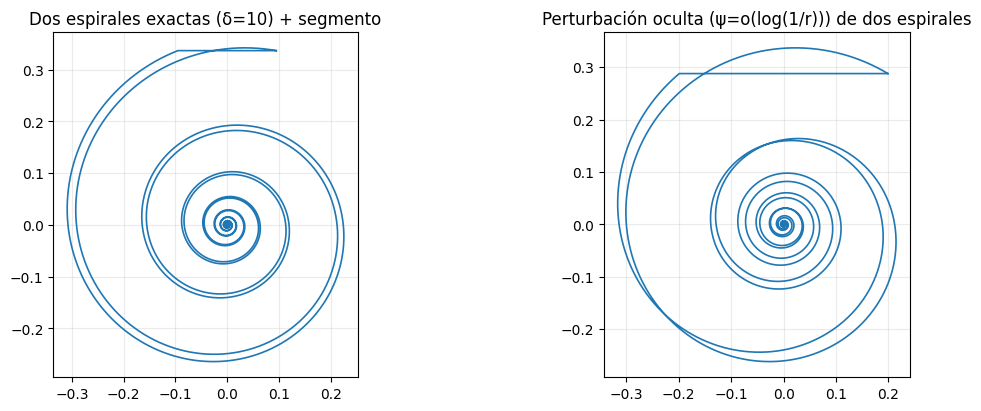

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Perturbación oculta: psi(r) = o(log(1/r))
#    Ejemplo típico: psi(r) = A * (log(1/r))^alpha * sin(omega*log log(1/r))
#    con 0<alpha<1  =>  psi(r) / log(1/r) -> 0
# ============================================================

def hidden_psi(r, A=0.8, alpha=0.6, omega=6.0, phase=0.0):
    """
    r in (0,1). Define L=log(1/r)->+infty as r->0.
    psi(r) = A * L^alpha * sin(omega*log L + phase), which is o(L) for alpha<1.
    """
    L = np.log(1.0 / r)
    return A * (L ** alpha) * np.sin(omega * np.log(L) + phase)


def hidden_perturbed_spiral(r, delta=10.0, beta=0.0, A=0.8, alpha=0.6, omega=6.0, phase=0.0,
                            radial_A=0.0, radial_alpha=0.6):
    """
    τ(r) = ρ(r) * exp(i θ(r))
    θ(r) = -delta log r + beta + psi(r), with psi(r)=o(log(1/r))  (hidden perturbation)
    ρ(r) = r*(1 + radial wobble), optional; keep wobble small to avoid self-intersections.
    """
    psi = hidden_psi(r, A=A, alpha=alpha, omega=omega, phase=phase)

    theta = -delta * np.log(r) + beta + psi

    if radial_A != 0.0:
        L = np.log(1.0 / r)
        # radial wobble that tends to 0: radial_A / L^radial_alpha
        wobble = radial_A / (L ** radial_alpha)
        rho = r * (1.0 + wobble * np.sin(omega * np.log(L) + phase))
    else:
        rho = r

    return rho * np.exp(1j * theta)


def build_hidden_perturbation_two_spirals(
    delta=10.0,
    beta1=0.0,
    beta2=0.55,         # separación angular entre ramas
    r_min=2e-4,
    r_max=0.35,
    n=12000,
    # perturbación angular (oculta)
    A=0.8,
    alpha=0.6,
    omega=6.0,
    phase1=0.0,
    phase2=1.3,
    # perturbación radial (opcional)
    radial_A=0.0,
    radial_alpha=0.6,
    # segmento de cierre
    seg_m=500,
    auto_rotate_segment=True
):
    # Rama 1: exterior -> origen
    r_in = np.linspace(r_max, r_min, n)
    z1 = hidden_perturbed_spiral(
        r_in, delta=delta, beta=beta1,
        A=A, alpha=alpha, omega=omega, phase=phase1,
        radial_A=radial_A, radial_alpha=radial_alpha
    )

    # Rama 2: origen -> exterior
    r_out = np.linspace(r_min, r_max, n)
    z2 = hidden_perturbed_spiral(
        r_out, delta=delta, beta=beta2,
        A=A, alpha=alpha, omega=omega, phase=phase2,
        radial_A=radial_A, radial_alpha=radial_alpha
    )

    # Puntos exteriores (sin necesidad de exactitud perfecta, tomamos los extremos)
    p1 = z1[0]   # inicio de rama1 en r_max
    p2 = z2[-1]  # fin de rama2 en r_max

    # Segmento de cierre
    seg = np.linspace(p2, p1, seg_m)

    z = np.concatenate([z1, z2, seg])

    if auto_rotate_segment:
        # rota para que el segmento quede horizontal (estético)
        ang = -np.angle(p1 - p2)
        z = z * np.exp(1j * ang)

    return z


def demo():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    # (A) Dos espirales logarítmicas exactas (sin perturbación)
    z_exact = build_hidden_perturbation_two_spirals(
        delta=10, beta1=0.0, beta2=0.55,
        A=0.0, alpha=0.6, omega=6.0,  # A=0 => sin perturbación angular
        radial_A=0.0
    )
    axes[0].plot(z_exact.real, z_exact.imag, lw=1.2)
    axes[0].set_title("Dos espirales exactas (δ=10) + segmento")
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].grid(True, alpha=0.25)

    # (B) Perturbación oculta de dos espirales
    z_hidden = build_hidden_perturbation_two_spirals(
        delta=10, beta1=0.0, beta2=0.55,
        A=0.9, alpha=0.6, omega=6.0,   # perturbación angular oculta
        radial_A=0.0
    )
    axes[1].plot(z_hidden.real, z_hidden.imag, lw=1.2)
    axes[1].set_title("Perturbación oculta (ψ=o(log(1/r))) de dos espirales")
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].grid(True, alpha=0.25)

    plt.show()


if __name__ == "__main__":
    demo()